
#**Tech Challenge - I - Sidney Filho** ⚡

##Entendendo o desafio



### Case E-commerce Olist

Este desafio propõe a construção de um relatório executivo voltado a
investidores e acionistas do setor de e-commerce, baseado no Brazilian E-Commerce
Public Dataset by Olist. O objetivo é transformar dados transacionais em uma narrativa
clara sobre desempenho comercial, eficiência logística e/ou satisfação do cliente,
culminando em recomendações acionáveis e, quando possível, previsões
fundamentadas.

### Organização dos dados

**Dataset**

O dataset reúne aproximadamente 100 mil pedidos entre 2016 e 2018, cobrindo
múltiplos marketplaces no Brasil. Inclui tabelas interconectadas de clientes, pedidos,
itens, produtos, vendedores, pagamentos, avaliações e geolocalização por CEP. Os
dados são reais e foram anonimizados. Há possibilidade de análises
multidimensionais, como status do pedido, preço, meios de pagamento, desempenho
de frete, localização, atributos de produto e reviews

**Estrutura dos Dados e Dicionário**

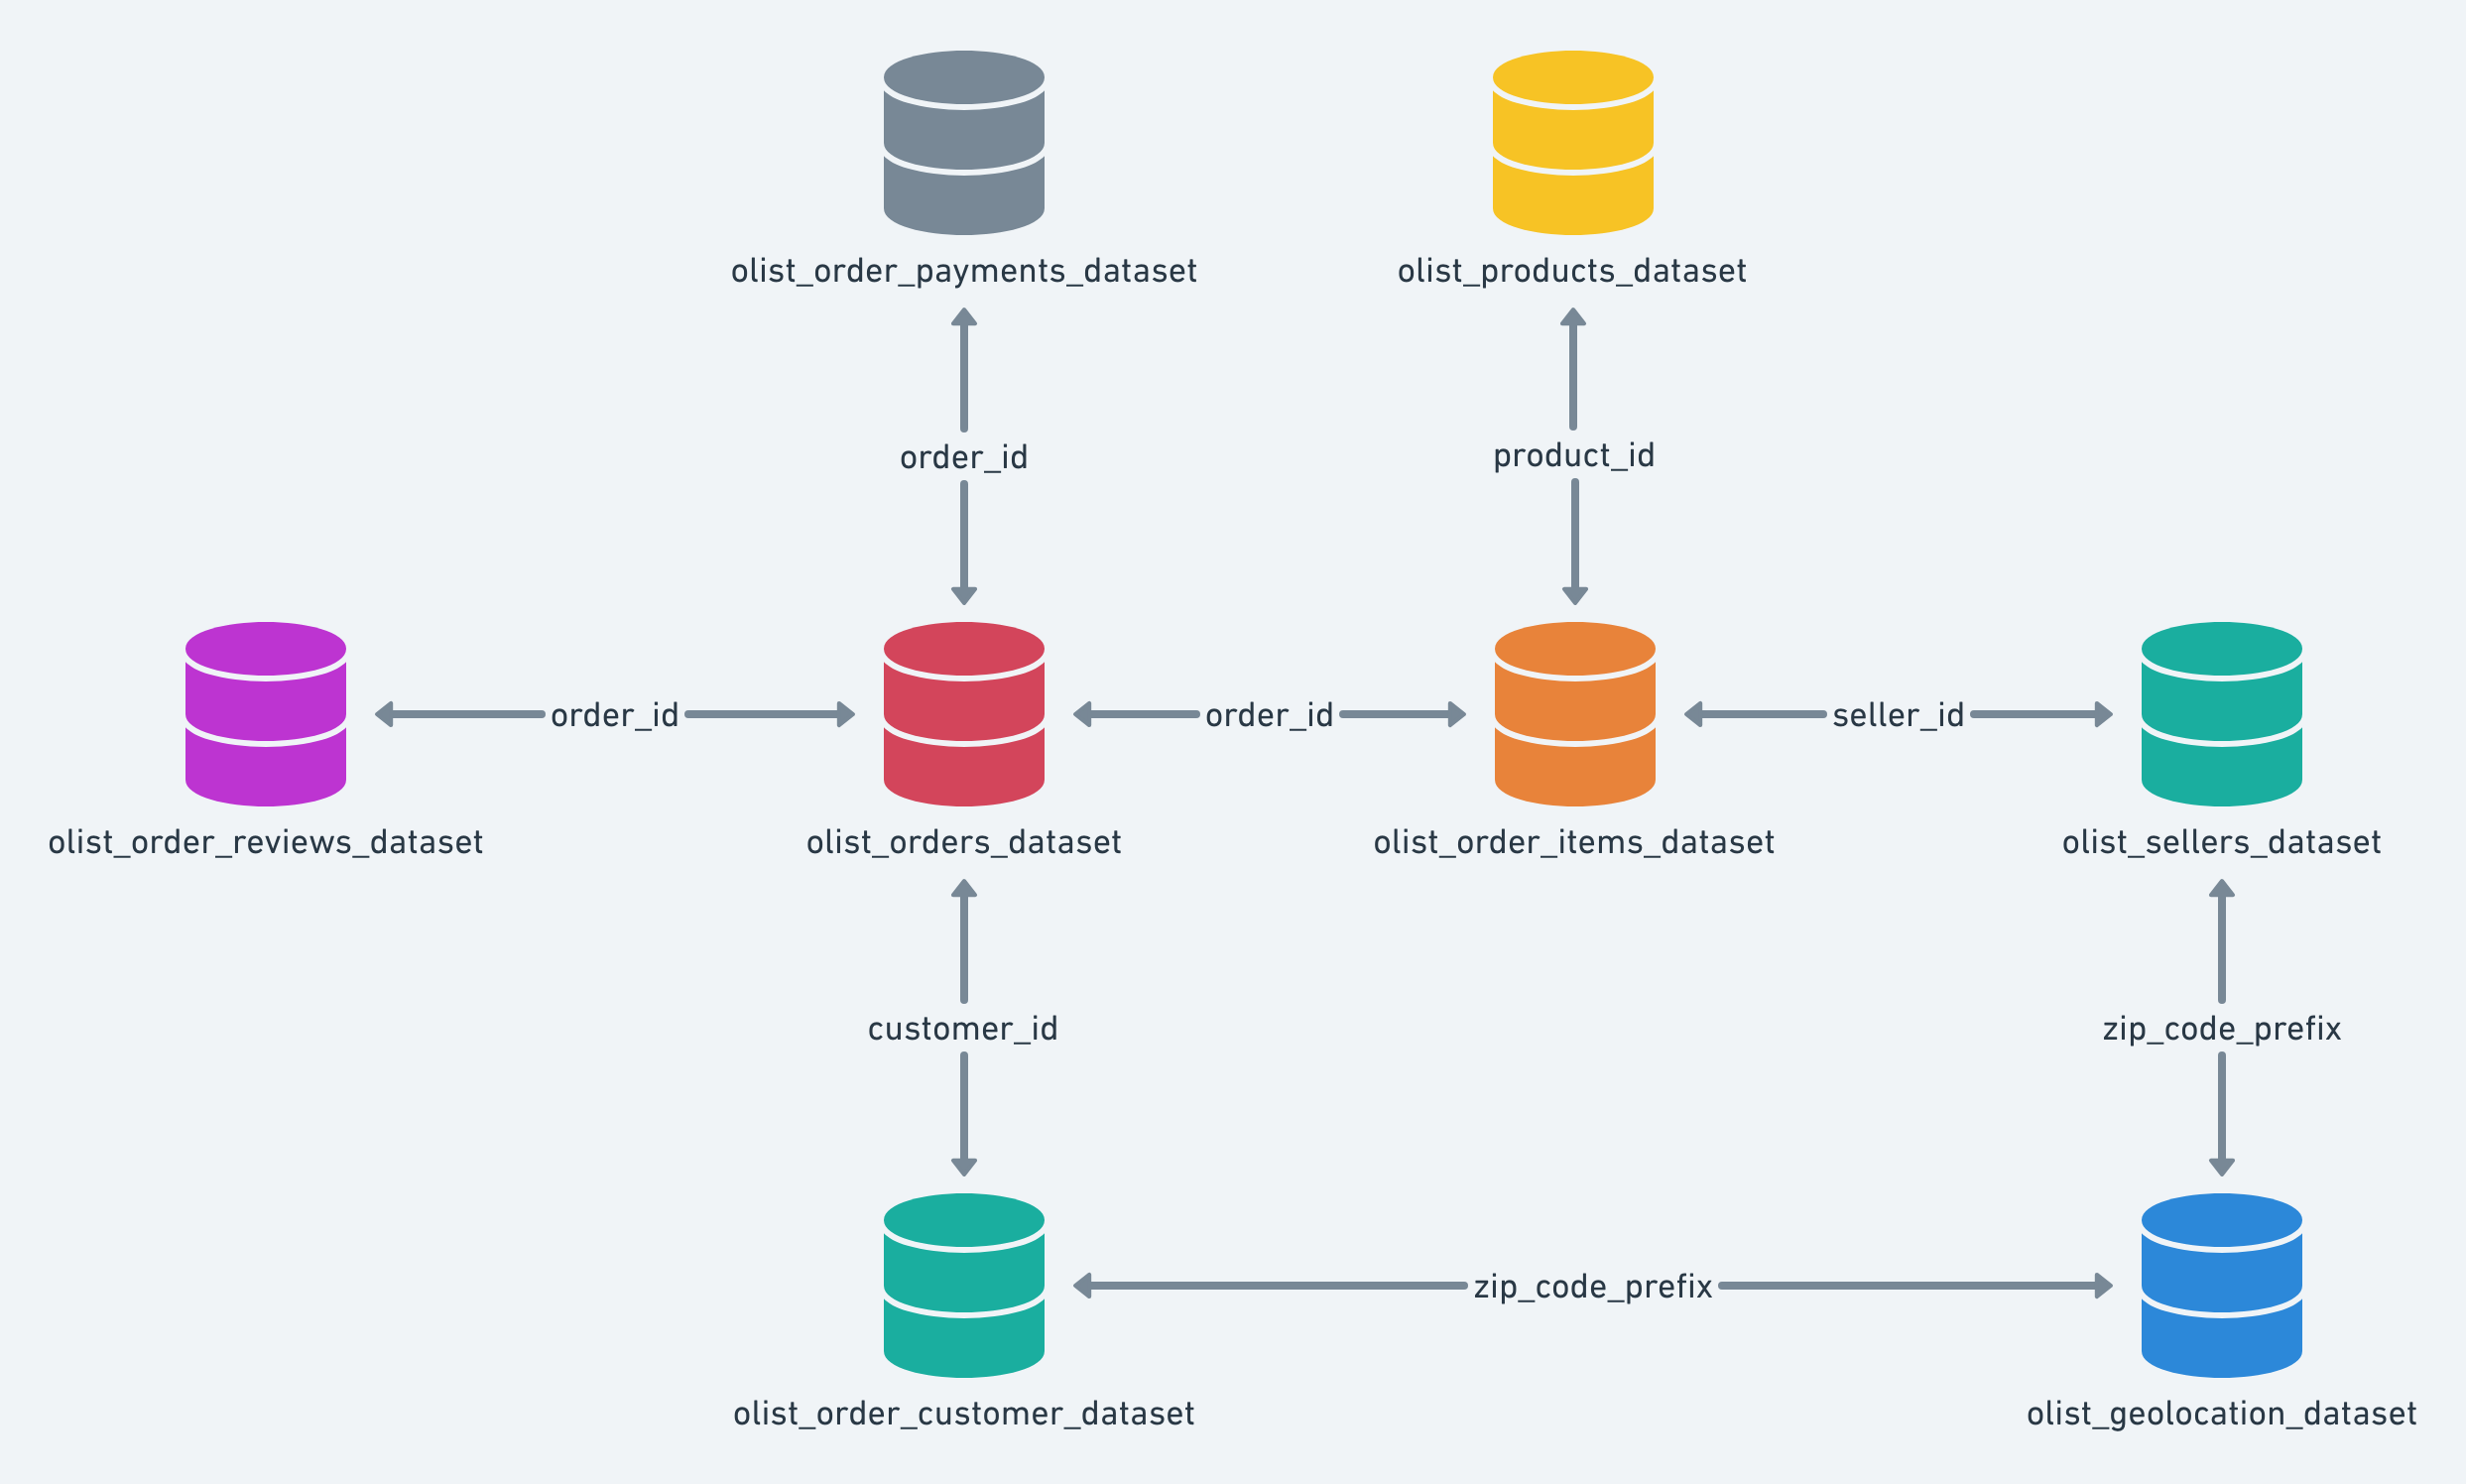

• customers: customer_id, customer_unique_id, zip_code_prefix, cidade,
estado.

• orders: order_id, customer_id, status, timestamps de
compra/aprovação/entrega.

• order_items: order_id, item_id, product_id, seller_id, shipping_limit_date,
price, freight_value.

• payments: order_id, payment_type, installments, payment_value.

• order_reviews: order_id, review_score, timestamps,
review_comment_title/text.

• products: product_id, category_name, pesos/medidas, descrição.

• sellers: seller_id, zip_code_prefix, cidade, estado.

• geolocation: zip_code_prefix, latitude, longitude, cidade, estado.

• category_translation: tradução de nomes de categorias para inglês

### Objetivo inicial

O objetivo inicial será avaliar os dados com foco no Crescimento e Receita:

• Evolução mensal de pedidos, receita e ticket médio.

• Participação por categoria e região (UF/município).

• Identificação de produtos e sellers top performers.



###KPIs

A **receita** corresponde ao total gerado pelas vendas de bens ou serviços, sendo uma das principais métricas de desempenho financeiro (Investopedia, 2023).

O **volume de pedidos** representa a quantidade de transações realizadas e é amplamente utilizado como indicador de desempenho comercial (Kotler & Keller, 2016).

O **ticket médio** (Average Order Value – AOV) mede o valor médio gasto por pedido, sendo calculado como a razão entre receita total e número de pedidos (Shopify, 2023).

A análise conjunta dessas métricas permite avaliar o crescimento do negócio, distinguindo se este é impulsionado por aumento de volume ou de valor por transação (McKinsey & Company).

### Importação de bibliotecas



###Carregamento de arquívos

##Dados - Evolução de pedidos + Receita

In [477]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

pd.set_option('display.max_columns', None)

In [478]:
orders = pd.read_csv('/content/olist_orders_dataset.csv')
items = pd.read_csv('/content/olist_order_items_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')
geo = pd.read_csv('/content/olist_geolocation_dataset.csv')
traducao = pd.read_csv('/content/product_category_name_translation.csv')

###Exploração Dataset

O formato dos dados estão de que forma? É preciso corrigir algo antes de continuar ? Vamos começar pelas datas, isso pode ajudar a garantir uma avaliação de período.

In [479]:
orders.head()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Alguns arquivos tem informação de datas, é preciso corrigir

In [480]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

Verificar correção

In [481]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [482]:
orders[['order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date']].head(7)


,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26
5,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01
6,2017-04-11 12:22:08,NaT,2017-05-09


Vamos validar a informação e fazer uma análise descritiva (ainda pensando em datas)

In [483]:
orders[[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]].describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
count,99441,96476,99441
mean,2017-12-31 08:43:12.776581120,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-10-17 13:22:46,2018-11-12 00:00:00


Quantas datas NaN temos destes arquívos ? Isso pode significar produtos não entregues, cancelados ou 'em andamento" ?

In [484]:
orders['order_delivered_customer_date'].isnull().sum()

np.int64(2965)

Vamos usar apenas os pedidos entregues!

In [485]:
df_orders_entregues = orders[orders['order_status'] == 'delivered']

In [486]:
df_orders_entregues['order_delivered_customer_date'].isnull().sum()

np.int64(8)

Como ainda temos entregas marcando como "NaN", vamos ter q remover para evitar leituras erradas dos dados

In [487]:
df_orders_entregues = df_orders_entregues[
    df_orders_entregues['order_delivered_customer_date'].notnull()
]
df_orders_entregues['order_delivered_customer_date'].isnull().sum()

np.int64(0)

Ok, com as datas certas, podemos focar agora no que diz respeito ao dinheiro

In [488]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


Os tipos das colunas parecem estar sendo interpretados corretamente, qual a análise descritiva do csv?

In [489]:
items[['price', 'freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


O negócio é em grande parte de produtos baratos, com alguns com alto valor puxando a média para cima ( 50% dos dados correspondem ao custo de '~75' , mas o valor máximo pode chegar a R$ 6735 ), o frete também pode oscilar bastante, a média esta em 19,99, mas o max esta em ~RS 410.

Como não temos uma coluna com receitam vamos unir preço com frete. Depois vamos unir a ordem do pedido ao valor agregado dele (se a pessoa comprou 5 itens, eles devem ser somados)





In [490]:
items['revenue'] = items['price'] + items['freight_value']

revenue_order = (
    items.groupby('order_id')['revenue']
    .sum()
    .reset_index()
)
df_base = df_orders_entregues.merge(revenue_order, on='order_id', how='left')

In [491]:
df_base.shape
df_base['order_id'].nunique()

96470

Existem itens nulos ?

In [492]:
df_base['revenue'].isnull().sum()

np.int64(0)

Agora vamos organizar por período, por exemplo mês/ano, isso vai permitir avaliar todos os meses do inicio ao fim do .cvs do banco de dados (de 2016-09-04 a 2017-10-17)

*Formato americano de data (YYYY/MM/DD)*

In [493]:
df_base['year_month'] = df_base['order_purchase_timestamp'].dt.to_period('M')

In [494]:
df_monthly = (
    df_base.groupby('year_month')
    .agg(
        pedidos=('order_id', 'nunique'),
        receita=('revenue', 'sum')
    )
    .reset_index()
)

df_monthly['ticket_medio'] = df_monthly['receita'] / df_monthly['pedidos']
df_monthly.head()

,year_month,pedidos,receita,ticket_medio
0,2016-09,1,143.46,143.460000
1,2016-10,265,46490.66,175.436453
2,2016-12,1,19.62,19.620000
3,2017-01,750,127482.37,169.976493
4,2017-02,1653,271239.32,164.089123


Vamos visualizar

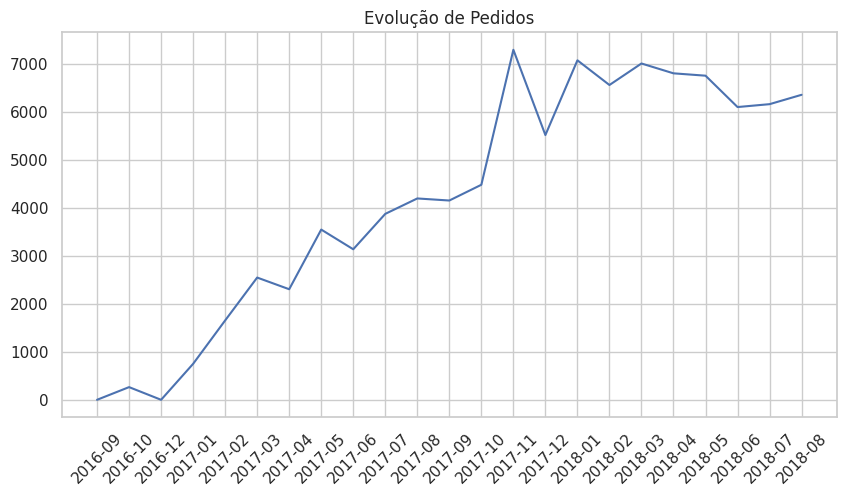

In [495]:
plt.figure(figsize=(10,5))
plt.plot(df_monthly['year_month'].astype(str), df_monthly['pedidos'])
plt.xticks(rotation=45)
plt.title('Evolução de Pedidos')
plt.show()

###Avaliação da Evolução dos pedidos ao longo dos meses

Ajuste para interpretação do gráfico

In [496]:
df_monthly['year_month'] = df_monthly['year_month'].dt.to_timestamp()

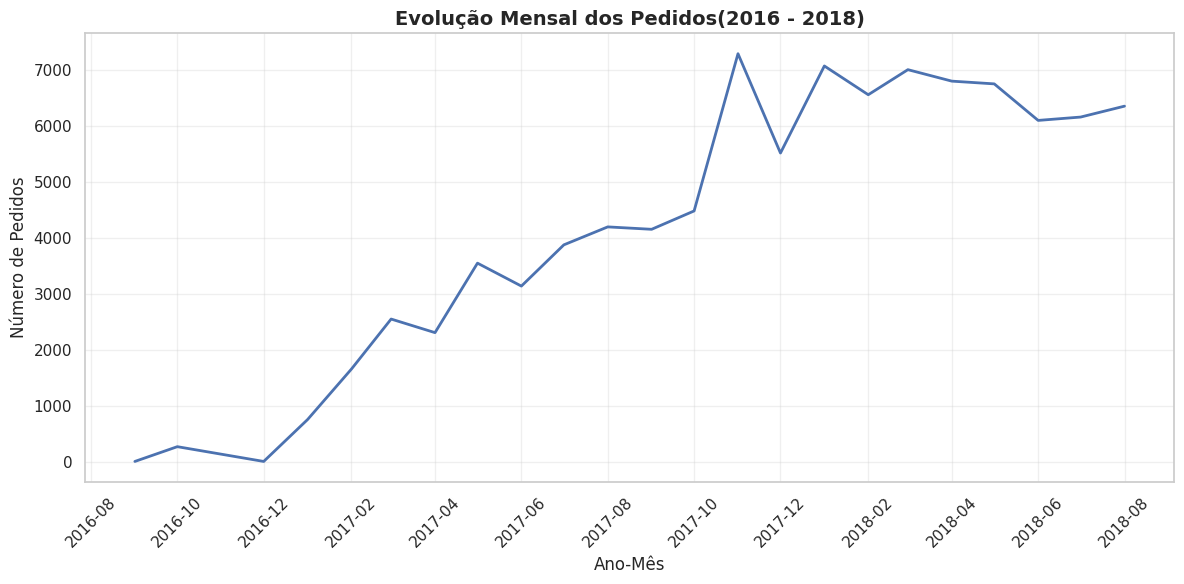

In [497]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(df_monthly['year_month'], df_monthly['pedidos'], linewidth=2)

# formatação do eixo
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.set_title('Evolução Mensal dos Pedidos(2016 - 2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de Pedidos')

ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

É possivel destacar o ápice de vendas (pedidos feitos) e a tendência inicial!

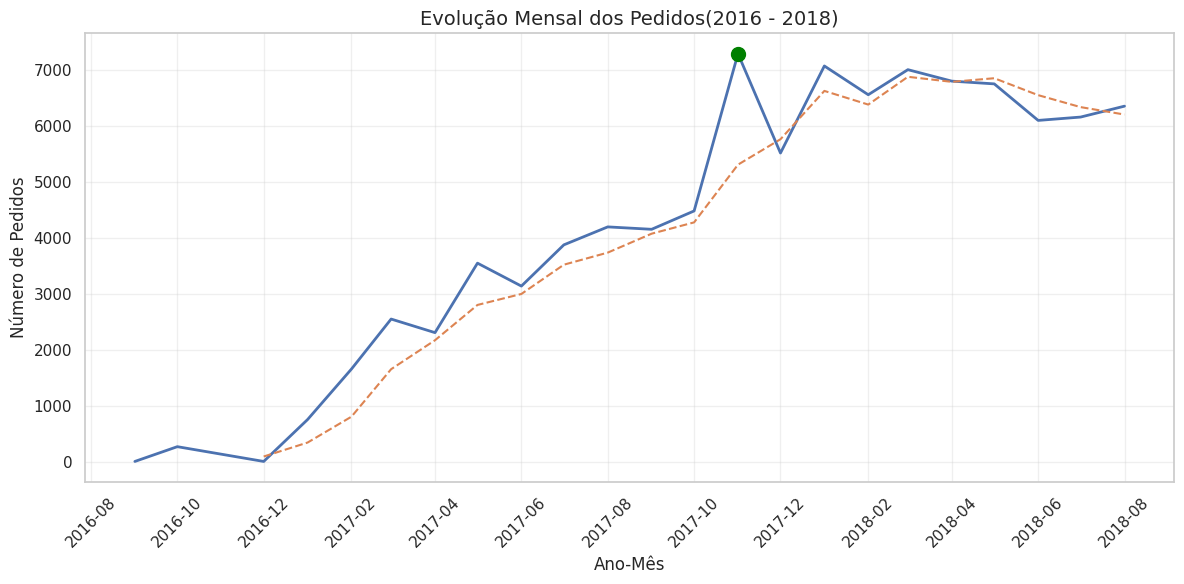

In [498]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(df_monthly['year_month'], df_monthly['pedidos'], linewidth=2)
df_monthly['rolling'] = df_monthly['pedidos'].rolling(3).mean()

# formatação do eixo
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.set_title('Evolução Mensal dos Pedidos(2016 - 2018)', fontsize=14)
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de Pedidos')

ax.grid(True, alpha=0.3)

#máximo de vendas
max_idx = df_monthly['pedidos'].idxmax()

plt.scatter(
    df_monthly.loc[max_idx, 'year_month'],
    df_monthly.loc[max_idx, 'pedidos'],
    s=100,
    color='green',
    zorder=5
)

#Tendência
sns.lineplot(
    data=df_monthly,
    x='year_month',
    y='rolling',
    linestyle='--'
)

plt.tight_layout()
plt.show()

Ajuste para cores do Olist  e estilo profissional (ajuda do Gimini)

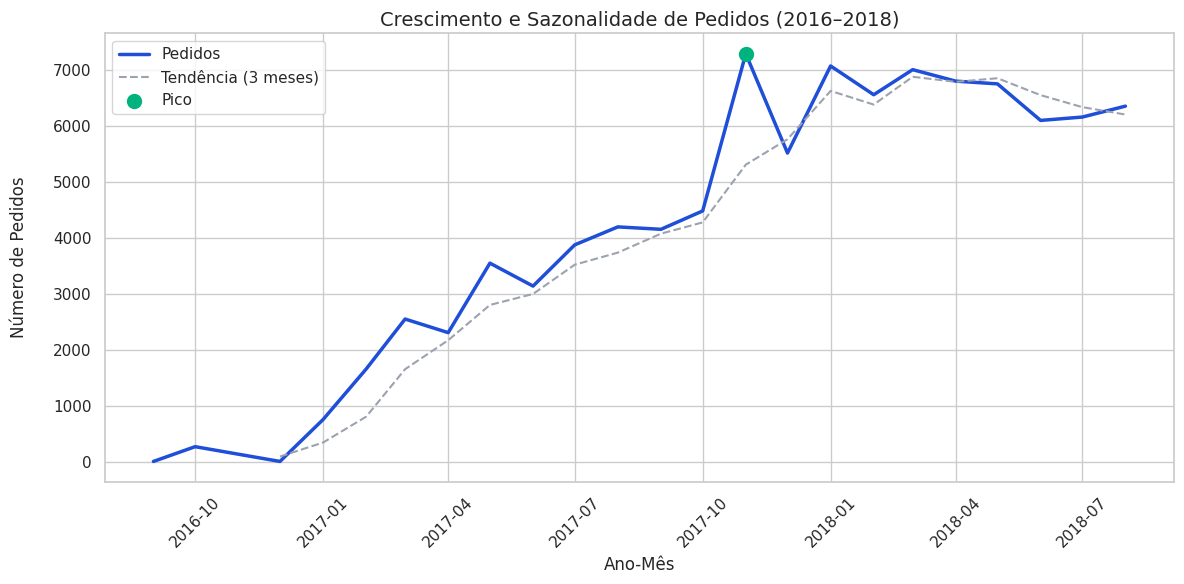

In [499]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

olist_blue = '#1f4ed8'
olist_green = '#00b37e'
olist_gray = '#9ca3af'

fig, ax = plt.subplots(figsize=(12,6))

# linha principal
sns.lineplot(
    data=df_monthly,
    x='year_month',
    y='pedidos',
    ax=ax,
    linewidth=2.5,
    color=olist_blue,
    label='Pedidos'
)

# média móvel
sns.lineplot(
    data=df_monthly,
    x='year_month',
    y='rolling',
    ax=ax,
    linestyle='--',
    color=olist_gray,
    label='Tendência (3 meses)'
)

# ponto de pico
max_idx = df_monthly['pedidos'].idxmax()

ax.scatter(
    df_monthly.loc[max_idx, 'year_month'],
    df_monthly.loc[max_idx, 'pedidos'],
    color=olist_green,
    s=100,
    zorder=5,
    label='Pico'
)

# título
ax.set_title('Crescimento e Sazonalidade de Pedidos (2016–2018)', fontsize=14)

# eixos
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Número de Pedidos', labelpad=18)

# legenda
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Avaliação da Receita ao longo dos meses

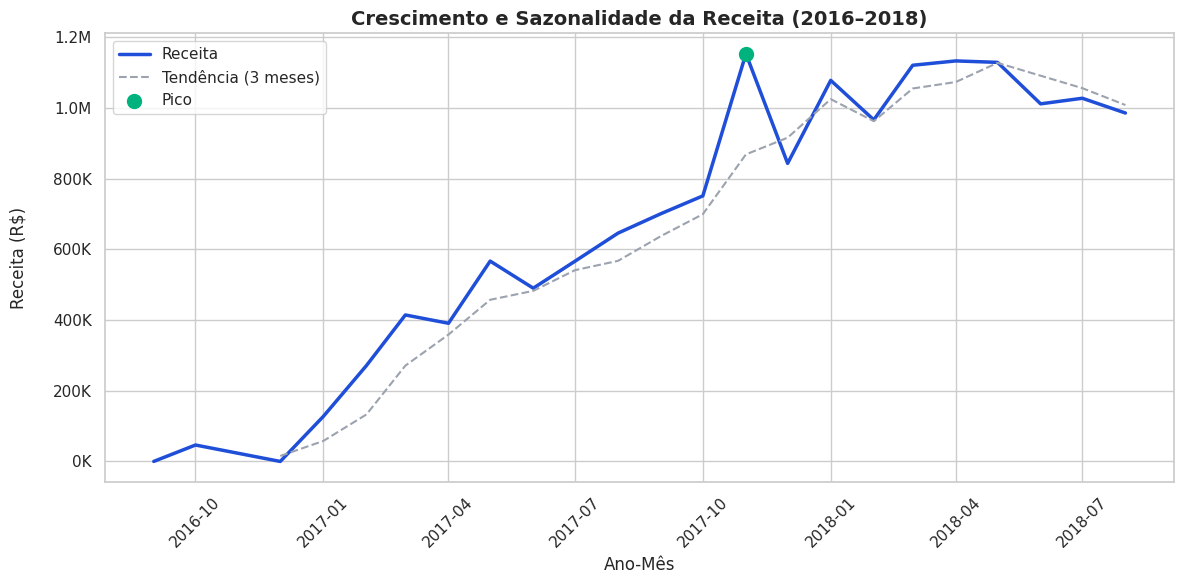

In [500]:
sns.set_theme(style="whitegrid")

olist_blue = '#1f4ed8'
olist_green = '#00b37e'
olist_gray = '#9ca3af'

def format_revenue(x, _):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    else:
        return f'{x/1e3:.0f}K'

fig, ax = plt.subplots(figsize=(12,6))

# linha principal
sns.lineplot(
    data=df_monthly,
    x='year_month',
    y='receita',
    ax=ax,
    linewidth=2.5,
    color=olist_blue,
    label='Receita'
)

# tendência
df_monthly['rolling_receita'] = df_monthly['receita'].rolling(3).mean()

sns.lineplot(
    data=df_monthly,
    x='year_month',
    y='rolling_receita',
    ax=ax,
    linestyle='--',
    color=olist_gray,
    label='Tendência (3 meses)'
)

# pico
max_idx = df_monthly['receita'].idxmax()

ax.scatter(
    df_monthly.loc[max_idx, 'year_month'],
    df_monthly.loc[max_idx, 'receita'],
    color=olist_green,
    s=100,
    zorder=5,
    label='Pico'
)

# formatação eixo Y
ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_revenue))

# títulos
ax.set_title('Crescimento e Sazonalidade da Receita (2016–2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Receita (R$)', labelpad=18)

ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Síntese

In [501]:
df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   year_month       23 non-null     datetime64[ns]
 1   pedidos          23 non-null     int64         
 2   receita          23 non-null     float64       
 3   ticket_medio     23 non-null     float64       
 4   rolling          21 non-null     float64       
 5   rolling_receita  21 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 1.2 KB


In [502]:
df_monthly.describe()

,year_month,pedidos,receita,ticket_medio,rolling,rolling_receita
count,23,23.000000,2.300000e+01,23.000000,21.000000,2.100000e+01
mean,2017-08-28 20:52:10.434782720,4194.347826,6.703650e+05,154.393522,4290.238095,6.858752e+05
min,2016-09-01 00:00:00,1.000000,1.962000e+01,19.620000,89.000000,1.555125e+04
25%,2017-03-16 12:00:00,2424.500000,4.025717e+05,153.475911,2798.000000,4.572669e+05
50%,2017-09-01 00:00:00,4193.000000,7.010775e+05,160.016884,4273.666667,6.993423e+05
75%,2018-02-15 00:00:00,6453.000000,1.019368e+06,167.063143,6379.000000,1.024732e+06
max,2018-08-01 00:00:00,7288.000000,1.153229e+06,175.436453,6875.666667,1.127417e+06
std,NaN,2480.924124,3.950855e+05,30.571908,2314.731614,3.689886e+05


In [503]:
df_monthly[['pedidos', 'receita', 'ticket_medio']]

,pedidos,receita,ticket_medio
0,1,143.46,143.460000
1,265,46490.66,175.436453
2,1,19.62,19.620000
3,750,127482.37,169.976493
4,1653,271239.32,164.089123
5,2546,414330.95,162.738001
6,2303,390812.40,169.697091
7,3545,566657.40,159.846939
8,3135,490050.37,156.315907
9,3872,566299.08,146.254928


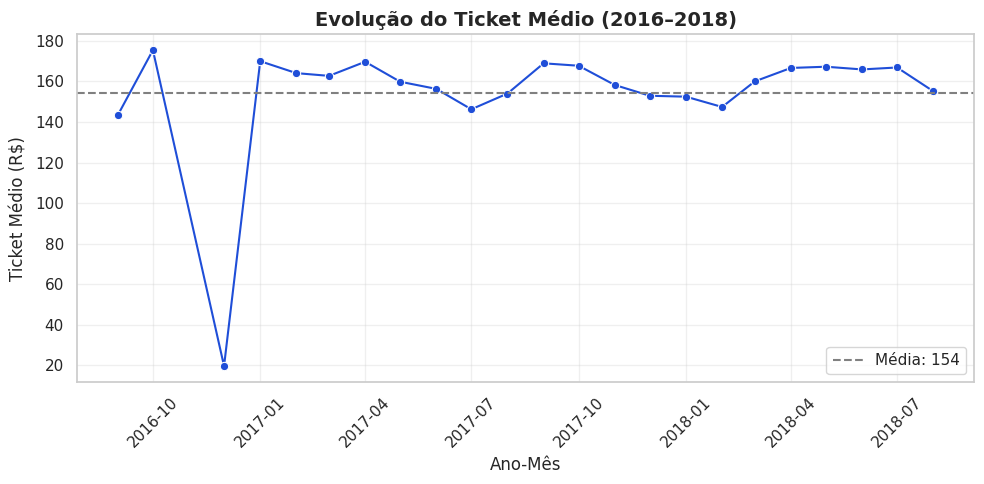

In [504]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_monthly,
    x='year_month',
    y='ticket_medio',
    marker='o',
    color='#1f4ed8'
)

media_ticket = df_monthly['ticket_medio'].mean()

plt.axhline(
    media_ticket,
    linestyle='--',
    color='gray',
    label=f'Média: {media_ticket:.0f}'
)

plt.legend()
plt.title('Evolução do Ticket Médio (2016–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Ano-Mês')
plt.ylabel('Ticket Médio (R$)', labelpad=5)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)



plt.tight_layout()
plt.show()

Temos um Outlier nítido

In [505]:
q1 = df_monthly['ticket_medio'].quantile(0.25)
q3 = df_monthly['ticket_medio'].quantile(0.75)
iqr = q3 - q1

outliers = df_monthly[
    (df_monthly['ticket_medio'] < q1 - 1.5 * iqr) |
    (df_monthly['ticket_medio'] > q3 + 1.5 * iqr)
]

outliers

,year_month,pedidos,receita,ticket_medio,rolling,rolling_receita
2,2016-12-01,1,19.62,19.62,89.0,15551.246667


neste ponto deve apenas 1 pedido, ele esta distorcendo a média de 154

In [506]:
df_monthly = df_monthly[df_monthly['pedidos'] >= 50]

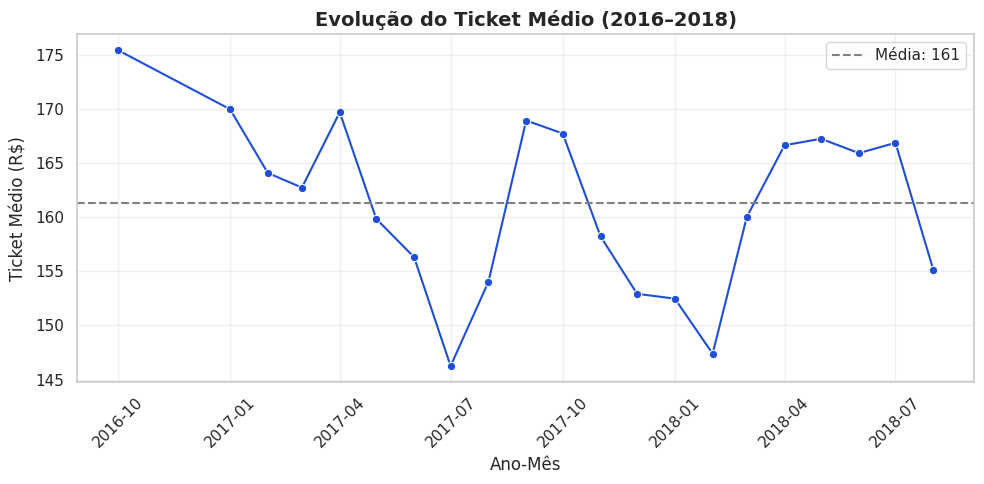

In [507]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_monthly,
    x='year_month',
    y='ticket_medio',
    marker='o',
    color='#1f4ed8'
)

media_ticket = df_monthly['ticket_medio'].mean()

plt.axhline(
    media_ticket,
    linestyle='--',
    color='gray',
    label=f'Média: {media_ticket:.0f}'
)

plt.legend()
plt.title('Evolução do Ticket Médio (2016–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Ano-Mês')
plt.ylabel('Ticket Médio (R$)', labelpad=5)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)



plt.tight_layout()
plt.show()

##Dados  - Participação por categoria e região (UF/município)

###Explorando o Dataset

In [508]:
items_cat = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

items_cat = items_cat.merge(
    traducao,
    on='product_category_name',
    how='left'
)

In [509]:
items_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   revenue                        112650 non-null  float64
 8   product_category_name          111047 non-null  object 
 9   product_category_name_english  111023 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 8.6+ MB


Criar receita por item

In [510]:
items_cat['revenue'] = items_cat['price'] + items_cat['freight_value']

Agregar por categoria

In [511]:
categoria = (
    items_cat.groupby('product_category_name_english')
    .agg(
        receita=('revenue', 'sum'),
        pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

Organizar por ordem decrescente

In [512]:
categoria = categoria.sort_values('receita', ascending=False).head(10)

In [513]:
categoria.describe()

,receita,pedidos
count,1.000000e+01,10.000000
mean,9.874243e+05,6166.600000
std,2.948036e+05,2092.875226
min,5.842192e+05,3518.000000
25%,7.340969e+05,4328.750000
50%,9.808921e+05,6166.500000
75%,1.220425e+06,7462.250000
max,1.441248e+06,9417.000000


###Categoria de Vendas

/tmp/ipykernel_12843/3754666367.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


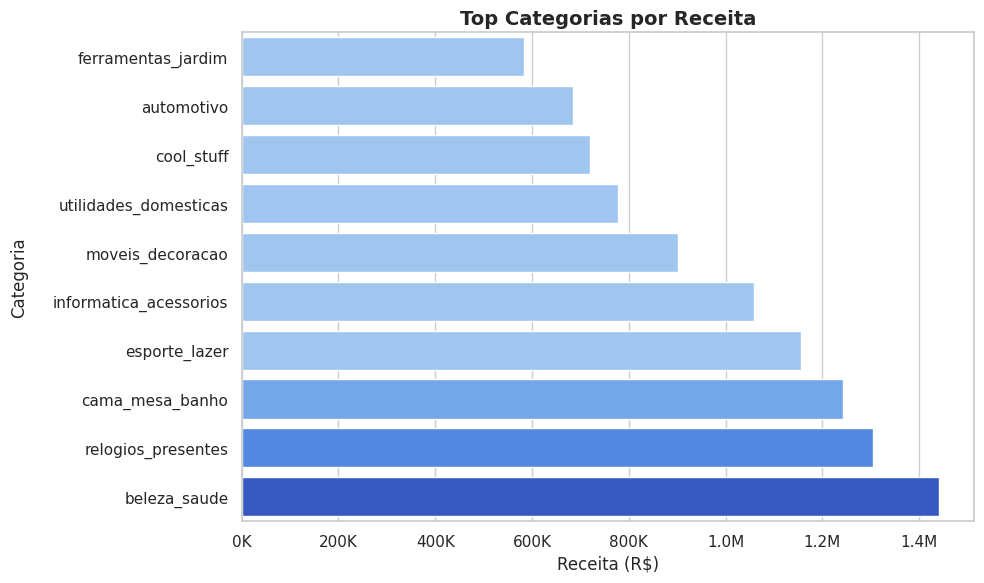

In [514]:
sns.set_theme(style="whitegrid")

# cores (estilo Olist)
olist_blue = '#1f4ed8'
olist_light = '#93c5fd'

def format_revenue(x, _):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    else:
        return f'{x/1e3:.0f}K'


# juntar categoria
items_cat = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# calcular receita
items_cat['receita'] = items_cat['price'] + items_cat['freight_value']

# agregar por categoria
categoria = (
    items_cat.groupby('product_category_name')
    .agg(
        receita=('receita', 'sum'),
        pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

# ordenar e pegar top 10
categoria = categoria.sort_values('receita', ascending=True).tail(10)

# -------------------------
# paleta híbrida (destaque top 3)
# -------------------------
colors = [olist_light] * len(categoria)

colors[-1] = olist_blue      # top 1
colors[-2] = '#3b82f6'       # top 2
colors[-3] = '#60a5fa'       # top 3

# -------------------------
# gráfico
# -------------------------

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=categoria,
    y='product_category_name',
    x='receita',
    palette=colors
)

# eixo X formatado
ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_revenue))

# títulos
ax.set_title('Top Categorias por Receita', fontsize=14, fontweight='bold')
ax.set_xlabel('Receita (R$)')
ax.set_ylabel('Categoria', labelpad=18)

plt.tight_layout()
plt.show()

In [515]:
# -------------------------
# agregar por categoria
# -------------------------
categoria = (
    items_cat.groupby('product_category_name')
    .agg(
        receita=('receita', 'sum'),
        pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

# ordenar e pegar top 10
categoria = categoria.sort_values('receita', ascending=True).tail(10)

# -------------------------
# traduzir categorias (AQUI!)
# -------------------------
mapa_nomes = {
    'ferramentas_jardim': 'Ferramentas de Jardim',
    'automotivo': 'Automotivo',
    'cool_stuff': 'Itens Diversos',
    'utilidades_domesticas': 'Utilidades Domésticas',
    'moveis_decoracao': 'Móveis e Decoração',
    'informatica_acessorios': 'Informática',
    'esporte_lazer': 'Esporte e Lazer',
    'cama_mesa_banho': 'Cama, Mesa e Banho',
    'relogios_presentes': 'Relógios e Presentes',
    'beleza_saude': 'Beleza e Saúde'
}

categoria['categoria_nome'] = categoria['product_category_name'].map(mapa_nomes)

categoria['categoria_nome'] = categoria['categoria_nome'].fillna(
    categoria['product_category_name'].str.replace('_', ' ').str.title()
)

/tmp/ipykernel_12843/599075270.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


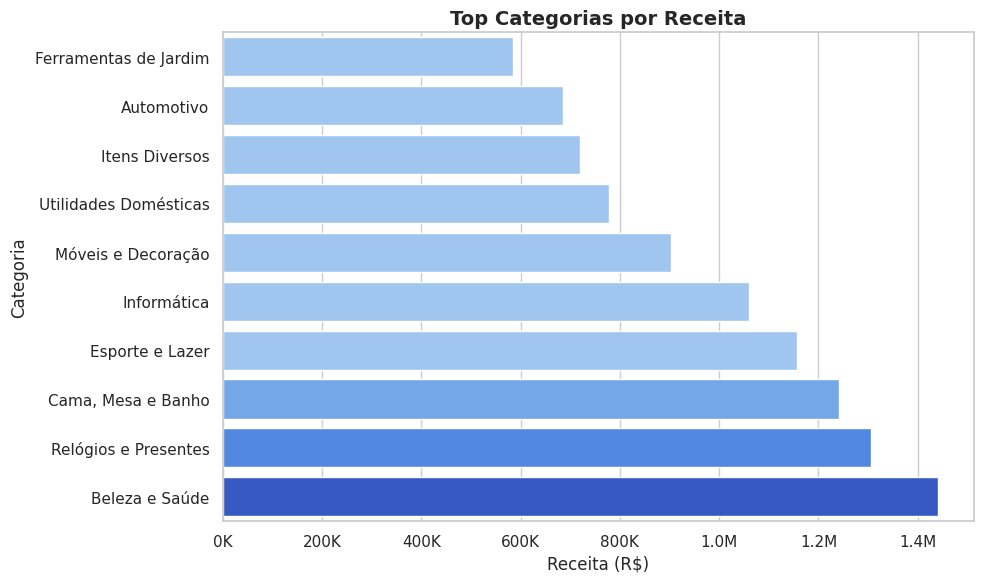

In [516]:
sns.set_theme(style="whitegrid")

# cores (estilo Olist)
olist_blue = '#1f4ed8'
olist_light = '#93c5fd'

fig, ax = plt.subplots(figsize=(10,6))

def format_revenue(x, _):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    else:
        return f'{x/1e3:.0f}K'

# -------------------------
# paleta híbrida (destaque top 3)
# -------------------------
colors = [olist_light] * len(categoria)

colors[-1] = olist_blue      # top 1
colors[-2] = '#3b82f6'       # top 2
colors[-3] = '#60a5fa'       # top 3

sns.barplot(
    data=categoria,
    y='categoria_nome',
    x='receita',
    palette=colors
)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_revenue))

plt.ylabel('Categoria', labelpad=5)
plt.xlabel('Receita (R$)')
plt.title('Top Categorias por Receita', fontsize=14, fontweight='bold')



plt.tight_layout()
plt.show()


organizar os nomes

In [517]:
mapa_nomes = {
    'ferramentas_jardim': 'Ferramentas de Jardim',
    'automotivo': 'Automotivo',
    'cool_stuff': 'Itens Diversos',
    'utilidades_domesticas': 'Utilidades Domésticas',
    'moveis_decoracao': 'Móveis e Decoração',
    'informatica_acessorios': 'Informática',
    'esporte_lazer': 'Esporte e Lazer',
    'cama_mesa_banho': 'Cama, Mesa e Banho',
    'relogios_presentes': 'Relógios e Presentes',
    'beleza_saude': 'Beleza e Saúde'
}

In [518]:
df_items_cat = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

In [519]:
df_base_cat = df_base.merge(
    df_items_cat[['order_id', 'product_category_name']],
    on='order_id',
    how='left'
)

In [520]:
df_items_cat['receita_item'] = df_items_cat['price'] + df_items_cat['freight_value']

df_cat = (
    df_items_cat
    .groupby('product_category_name')
    .agg(receita=('receita_item', 'sum'))
    .reset_index()
)

### Organizar por estados

In [521]:
df_regiao = df_orders_entregues.merge(
    revenue_order,
    on='order_id',
    how='left'
)

df_regiao = df_regiao.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)


In [522]:
df_regiao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  object        
 1   customer_id                    96470 non-null  object        
 2   order_status                   96470 non-null  object        
 3   order_purchase_timestamp       96470 non-null  datetime64[ns]
 4   order_approved_at              96456 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96469 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96470 non-null  datetime64[ns]
 8   revenue                        96470 non-null  float64       
 9   customer_state                 96470 non-null  object        
dtypes: datetime64[ns](5), float64(1), object(4)
memory usage: 7.4+ MB


In [523]:
# receita por pedido
revenue_order = (
    items.assign(receita=lambda x: x['price'] + x['freight_value'])
    .groupby('order_id')['receita']
    .sum()
    .reset_index()
)

# juntar com pedidos entregues
df_regiao = df_orders_entregues.merge(
    revenue_order,
    on='order_id',
    how='left'
)

# adicionar estado
df_regiao = df_regiao.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

In [524]:
df_regiao.head()
df_regiao.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'receita', 'customer_state'],
      dtype='object')

Algum campo nulo?

In [525]:
df_regiao['customer_state'].isnull().sum()

np.int64(0)

In [526]:
df_regiao = df_regiao.dropna(subset=['customer_state', 'receita'])

In [527]:
regiao = (
    df_regiao.groupby('customer_state')
    .agg(
        receita=('receita', 'sum'),
        pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

regiao = regiao.sort_values('receita', ascending=True)

Grafico inicial

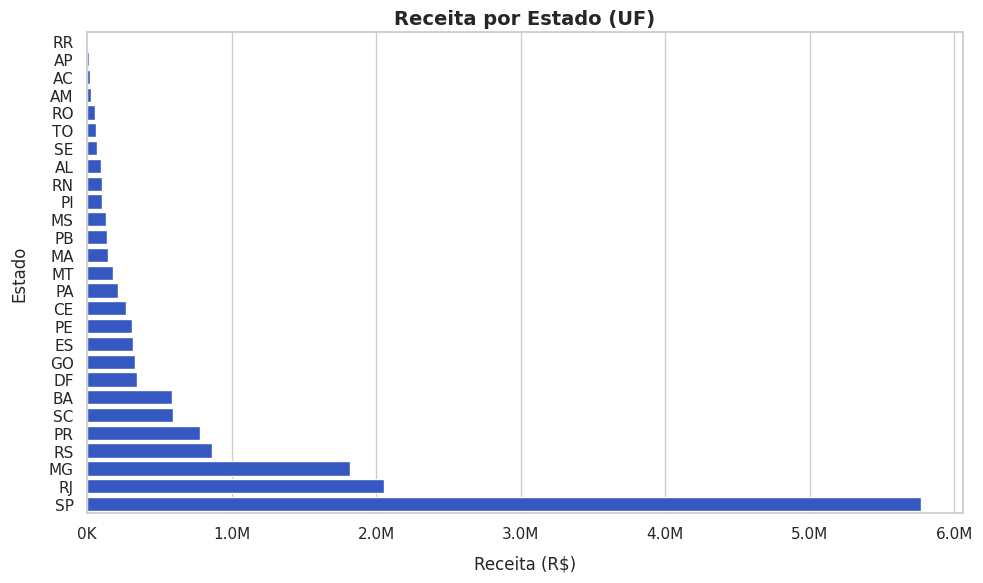

In [528]:
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=regiao,
    y='customer_state',
    x='receita',
    color=olist_blue
)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_revenue))

ax.set_title('Receita por Estado (UF)', fontsize=14, fontweight='bold')
ax.set_xlabel('Receita (R$)', labelpad=10)
ax.set_ylabel('Estado', labelpad=15)

plt.tight_layout()
plt.show()

Vamos tratar um pouco

/tmp/ipykernel_12843/2013122065.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_12843/2013122065.py:25: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


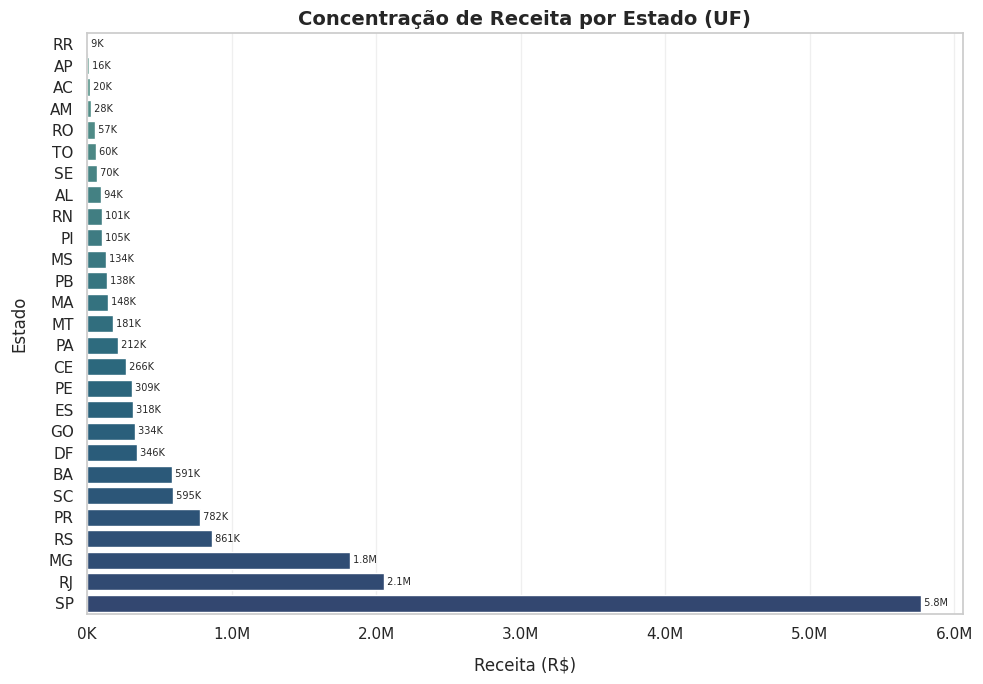

In [529]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np

sns.set_theme(style="whitegrid")

# função receita
def format_revenue(x, _):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    else:
        return f'{x/1e3:.0f}K'

# ordenar
regiao = regiao.sort_values('receita', ascending=True)

# colormap crest
cmap = sns.color_palette("crest", as_cmap=True)
colors = cmap(np.linspace(0.3, 0.9, len(regiao)))

# gráfico
fig, ax = plt.subplots(figsize=(10,7))

sns.barplot(
    data=regiao,
    y='customer_state',
    x='receita',
    palette=colors
)

ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_revenue))

ax.set_title(
    'Concentração de Receita por Estado (UF)',
    fontsize=14,
    fontweight='bold'
)

for i, v in enumerate(regiao['receita']):
    ax.text(
        v,
        i,
        f' {format_revenue(v, None)}',
        va='center',
        fontsize=7
    )

ax.set_xlabel('Receita (R$)', labelpad=10)
ax.set_ylabel('Estado', labelpad=15)

ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', alpha=0)

plt.tight_layout()
plt.show()

E se focarmos no TOP 5 estados?

In [530]:
regiao_top5 = regiao.sort_values('receita', ascending=False).head(5)
regiao_top5 = regiao_top5.sort_values('receita', ascending=True)

### Estados com maior receita

/tmp/ipykernel_12843/589958694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_12843/589958694.py:3: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(
/tmp/ipykernel_12843/589958694.py:3: UserWarning: The palette list has more values (27) than needed (5), which may not be intended.
  sns.barplot(


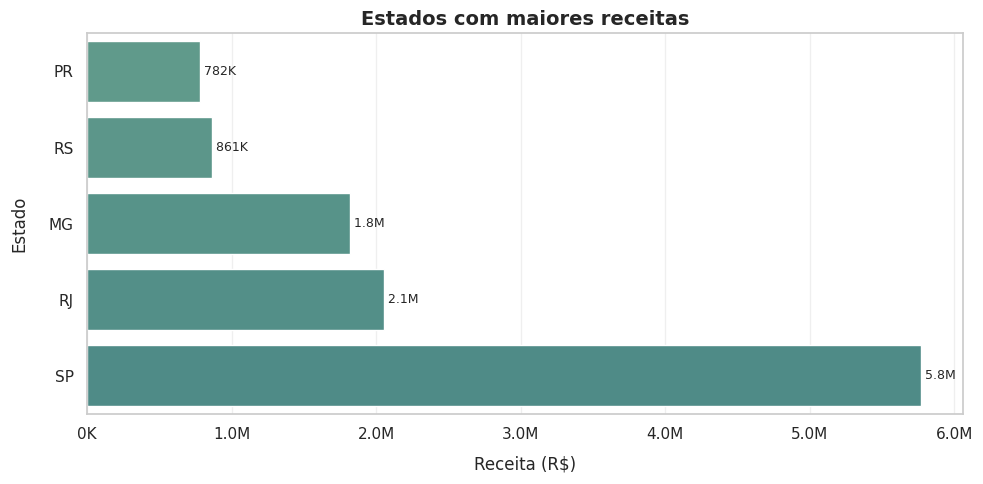

In [531]:
fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(
    data=regiao_top5,
    y='customer_state',
    x='receita',
    palette=colors
)

olist_blue = '#1f4ed8'
olist_mid = '#3b82f6'
olist_soft = '#60a5fa'
olist_light = '#93c5fd'

colors = [olist_light] * len(regiao_top5)

colors[-1] = olist_blue   # SP
colors[-2] = olist_mid    # RJ
colors[-3] = olist_soft   # MG

ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_revenue))

ax.set_title(
    'Estados com maiores receitas',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Receita (R$)', labelpad=10)
ax.set_ylabel('Estado', labelpad=15)

ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', alpha=0)

# valores nas barras
for i, v in enumerate(regiao_top5['receita']):
    ax.text(
        v,
        i,
        f' {format_revenue(v, None)}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

E a que categoria cada uma dessas receita pertence?

In [532]:
# juntar tudo: pedidos + receita + estado + categoria
df_cat_regiao = df_orders_entregues.merge(
    items.assign(receita=lambda x: x['price'] + x['freight_value']),
    on='order_id',
    how='left'
)

df_cat_regiao = df_cat_regiao.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

df_cat_regiao = df_cat_regiao.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

In [533]:
cat_regiao = (
    df_cat_regiao.groupby(['customer_state', 'product_category_name'])
    .agg(receita=('receita', 'sum'))
    .reset_index()
)

Filtrar

In [534]:
top5_estados = regiao_top5['customer_state'].tolist()

cat_regiao = cat_regiao[
    cat_regiao['customer_state'].isin(top5_estados)
]

organizar

In [535]:
pivot = cat_regiao.pivot_table(
    index='customer_state',
    columns='product_category_name',
    values='receita',
    fill_value=0
)

In [536]:
top_categorias = (
    cat_regiao.groupby('product_category_name')['receita']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

pivot = pivot[top_categorias]

In [537]:
df_plot = pivot.reset_index()
df_plot = df_plot.melt(
    id_vars='customer_state',
    var_name='categoria',
    value_name='receita'
)

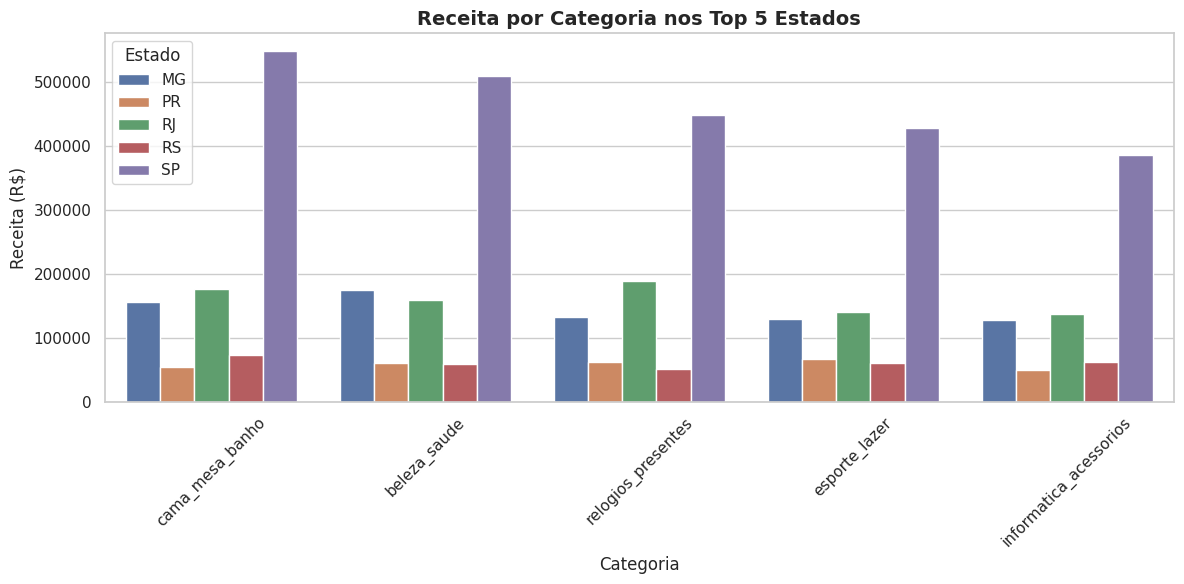

In [538]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_plot,
    x='categoria',
    y='receita',
    hue='customer_state'
)

plt.title('Receita por Categoria nos Top 5 Estados', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Receita (R$)')

plt.xticks(rotation=45)

plt.legend(title='Estado')

plt.tight_layout()
plt.show()

Fica dificil de visualisar, quem sabe usar percentual ?

In [539]:
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
pivot_pct = pivot_pct * 100

In [540]:
df_pct = pivot_pct.reset_index()

df_pct = df_pct.melt(
    id_vars='customer_state',
    var_name='categoria',
    value_name='percentual'
)

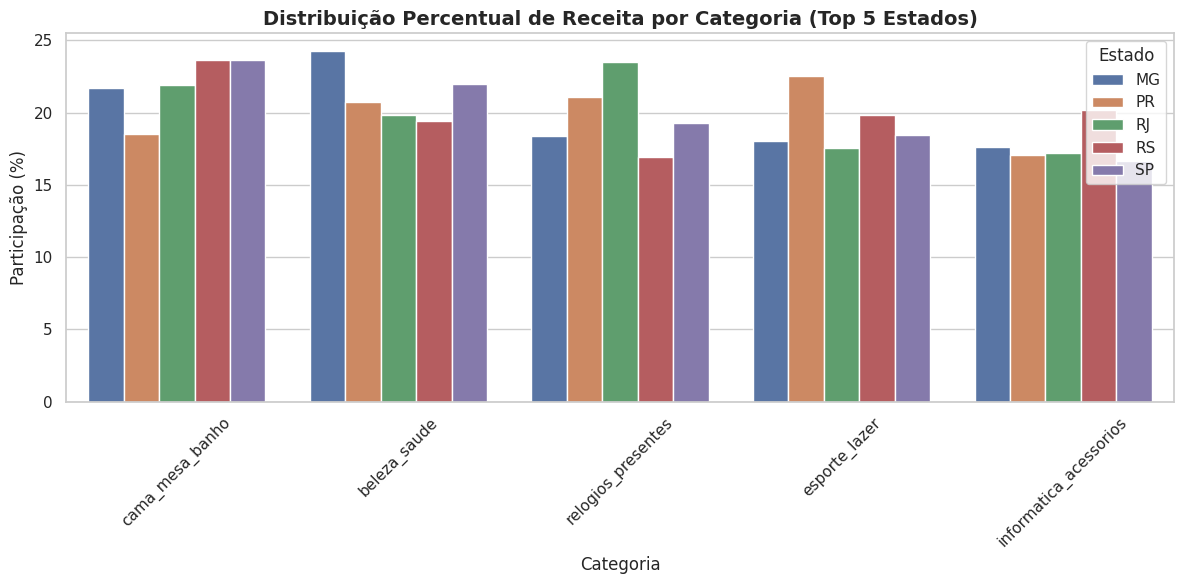

In [541]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_pct,
    x='categoria',
    y='percentual',
    hue='customer_state'
)

plt.title('Distribuição Percentual de Receita por Categoria (Top 5 Estados)', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Participação (%)')

plt.xticks(rotation=45)

plt.legend(title='Estado')

plt.tight_layout()
plt.show()

Forma incorreta de apresentação

In [542]:
categorias = df_pct['categoria'].unique()

mapa_cat = {cat: i+1 for i, cat in enumerate(categorias)}

df_pct['categoria_cod'] = df_pct['categoria'].map(mapa_cat)

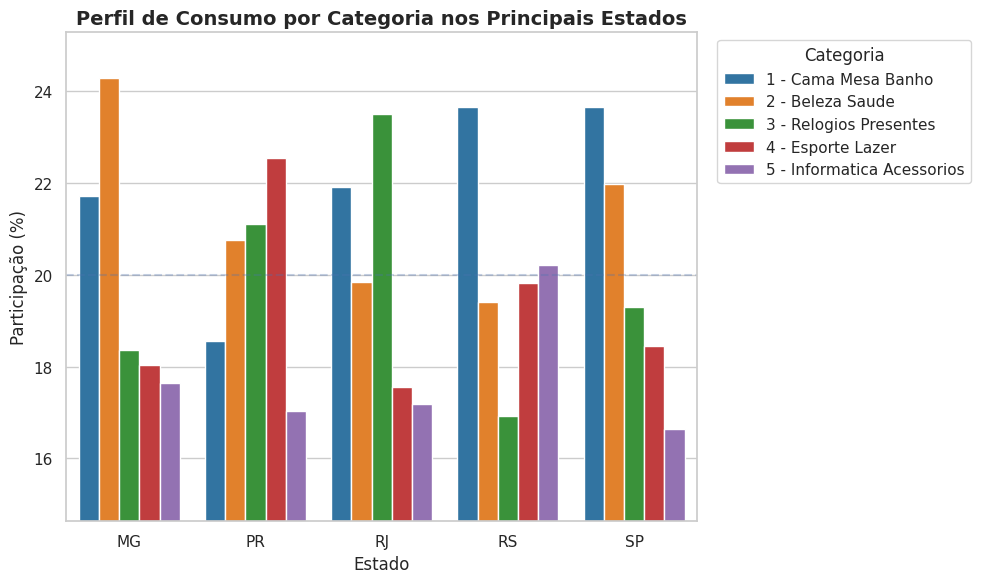

In [543]:
import matplotlib.pyplot as plt
import seaborn as sns

# paleta primeiro
olist_palette = [
    '#dbeafe',
    '#93c5fd',
    '#60a5fa',
    '#3b82f6',
    '#1f4ed8'
]

# criar figura corretamente
fig, ax = plt.subplots(figsize=(10,6))

# cores
palette = sns.color_palette("tab10", 5)

sns.barplot(
    data=df_pct,
    x='customer_state',
    y='percentual',
    hue='categoria_cod',
    palette=palette,
    ax=ax
)

# título
ax.set_title(
    'Perfil de Consumo por Categoria nos Principais Estados',
    fontsize=14,
    fontweight='bold'
)

#categorias
mapa_nomes = {
    'cama_mesa_banho': 'Cama, Mesa e Banho',
    'beleza_saude': 'Beleza e Saúde',
    'relogios_presentes': 'Relógios e Presentes',
    'esporte_lazer': 'Esporte e Lazer',
    'informatica_acessorios': 'Informática'
}

# labels eixo
y_min = df_pct['percentual'].min() - 2
y_max = df_pct['percentual'].max() + 1

ax.set_ylim(y_min, y_max)

ax.set_xlabel('Estado')
ax.set_ylabel('Participação (%)')

# legenda customizada
handles, labels = ax.get_legend_handles_labels()

labels_custom = [
    f"{cod} - {cat.replace('_', ' ').title()}"
    for cat, cod in mapa_cat.items()
]

ax.legend(
    handles,
    labels_custom,
    title='Categoria',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
#Grid
ax.axhline(20, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Explorando Dataset Logistica

In [544]:
df_logistica = df_orders_entregues.copy()

# garantir datetime
cols = [
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]

for col in cols:
    df_logistica[col] = pd.to_datetime(df_logistica[col])

# -------------------------
# cálculos (em dias)
# -------------------------

df_logistica['tempo_aprovacao_postagem'] = (
    df_logistica['order_delivered_carrier_date'] - df_logistica['order_approved_at']
).dt.days

df_logistica['tempo_postagem_entrega'] = (
    df_logistica['order_delivered_customer_date'] - df_logistica['order_delivered_carrier_date']
).dt.days

df_logistica['tempo_total'] = (
    df_logistica['order_delivered_customer_date'] - df_logistica['order_approved_at']
).dt.days

In [545]:
df_logistica[['tempo_aprovacao_postagem',
              'tempo_postagem_entrega',
              'tempo_total']].describe()

,tempo_aprovacao_postagem,tempo_postagem_entrega,tempo_total
count,96455.000000,96469.000000,96456.000000
mean,2.295672,8.878054,11.642459
std,3.548012,8.745881,9.520355
min,-172.000000,-17.000000,-7.000000
25%,0.000000,4.000000,6.000000
50%,1.000000,7.000000,9.000000
75%,3.000000,12.000000,15.000000
max,125.000000,205.000000,208.000000


Foram identificadas inconsistências temporais nos dados, com registros apresentando lead times negativos, indicando possíveis erros de registro ou integração de sistemas.

In [546]:
df_logistica_clean = df_logistica[
    (df_logistica['tempo_aprovacao_postagem'] >= 0) &
    (df_logistica['tempo_postagem_entrega'] >= 0) &
    (df_logistica['tempo_total'] >= 0)
]

Avaliar numero de perdas

In [547]:
len(df_logistica), len(df_logistica_clean)

(96470, 95082)

In [548]:
df_logistica_clean[['tempo_aprovacao_postagem',
                    'tempo_postagem_entrega',
                    'tempo_total']].describe()

,tempo_aprovacao_postagem,tempo_postagem_entrega,tempo_total
count,95082.000000,95082.000000,95082.000000
mean,2.351581,8.910320,11.727256
std,3.490630,8.755815,9.532078
min,0.000000,0.000000,0.000000
25%,0.000000,4.000000,6.000000
50%,1.000000,7.000000,9.000000
75%,3.000000,12.000000,15.000000
max,125.000000,205.000000,208.000000


Exploração para ter um perfil do tempo de entrega que cada tipo de produto esta levando para ser entregue

In [549]:
df_cat_log = df_logistica_clean.merge(
    items[['order_id', 'product_id']],
    on='order_id',
    how='left'
)

df_cat_log = df_cat_log.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

cat_tempo = (
    df_cat_log.groupby('product_category_name')
    .agg(
        tempo_medio=('tempo_total', 'mean'),
        pedidos=('order_id', 'nunique')
    )
    .reset_index()
)

Organizar por ordem Decrescente

In [550]:
top_cat = cat_tempo.sort_values('pedidos', ascending=False).head(10)

top_cat = top_cat.sort_values('tempo_medio', ascending=True)

Visualizar

In [551]:
mapa_nomes = {
    'utilidades_domesticas': 'Utilidades Domésticas',
    'brinquedos': 'Brinquedos',
    'beleza_saude': 'Beleza e Saúde',
    'esporte_lazer': 'Esporte e Lazer',
    'automotivo': 'Automotivo',
    'relogios_presentes': 'Relógios e Presentes',
    'telefonia': 'Telefonia',
    'moveis_decoracao': 'Móveis e Decoração',
    'cama_mesa_banho': 'Cama, Mesa e Banho',
    'informatica_acessorios': 'Informática'
}

In [552]:
top_cat['categoria_nome'] = top_cat['product_category_name'].map(mapa_nomes)

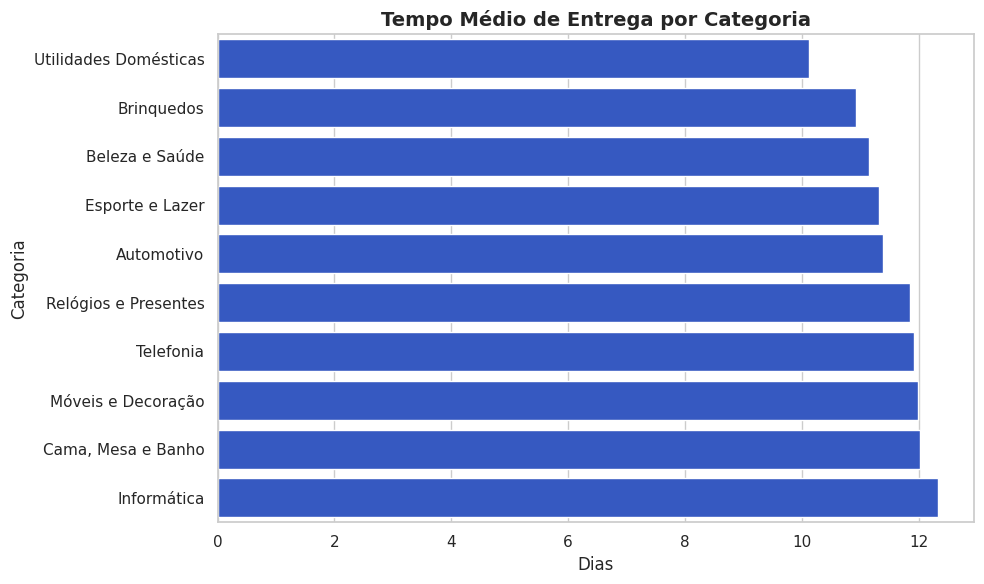

In [553]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_cat,
    y='categoria_nome',
    x='tempo_medio',
    color='#1f4ed8'
)


#
plt.title('Tempo Médio de Entrega por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Dias')
plt.ylabel('Categoria')

plt.tight_layout()
plt.show()